# Runtime Comparison: karambola (C++) vs pykarambola vs pykarambola[accel]

This notebook has three independent parts:

| Part | Description | Requires |
|------|-------------|----------|
| **1 — Mesh generation** | Build icospheres, save as `.off` files | nothing |
| **2 — pykarambola timing** | Pure-Python and Cython-accelerated runs | Part 1 |
| **3 — Three-way comparison** | Load karambola results, compare all three | Parts 1–2 + karambola run |

**Analytical reference for a unit sphere** (`R = 1`):  
All four Minkowski scalars converge to `4π/3 ≈ 4.18879`.

In [1]:
import os
import sys
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import pykarambola
from pykarambola import minkowski_tensors, parse_off_file, LABEL_UNASSIGNED

assert Path.cwd().name == 'notebooks', (
    f"Expected CWD to be 'paper/notebooks/', got: {Path.cwd()}\n"
    "Please launch Jupyter from the paper/notebooks/ directory."
)

print(f"pykarambola version: {pykarambola.__version__}")

# Check whether the Cython accel module is compiled
try:
    import pykarambola._accel
    _ACCEL_AVAILABLE = True
except ImportError:
    _ACCEL_AVAILABLE = False
print(f"Cython accel available: {_ACCEL_AVAILABLE}")

pykarambola version: 0.3.0
Cython accel available: True


In [2]:
# ── Configuration ─────────────────────────────────────────────────────────────
R       = 1.0
SUBDIVS = list(range(5, 11))   # 5 → 10 242 verts … 10 → 10 485 762 verts

# sub=11 (41 943 042 verts) is commented out — our pure-numpy icosphere builds
# vertices as a Python list of arrays (~4–5 GB overhead vs trimesh's contiguous
# arrays). Uncomment only if you have sufficient RAM (~30 GB+).
# SUBDIVS = list(range(5, 12))

REPO_ROOT   = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
OFF_DIR     = os.path.join(REPO_ROOT, "dataset", "basic_shapes", "runtime_tests")
RESULTS_DIR = os.path.join(os.getcwd(), "results")
KARA_DIR    = os.path.join(REPO_ROOT, "dataset", "karambola_results",
                           "basic_shapes", "runtime_tests")

os.makedirs(OFF_DIR,     exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"OFF output dir : {OFF_DIR}")
print(f"karambola dir  : {KARA_DIR}")
print(f"Results dir    : {RESULTS_DIR}")

OFF output dir : /Users/yajushikhurana/Desktop/pykarambola_ishiharalab_mac/pykarambola/dataset/basic_shapes/runtime_tests
karambola dir  : /Users/yajushikhurana/Desktop/pykarambola_ishiharalab_mac/pykarambola/dataset/karambola_results/basic_shapes/runtime_tests
Results dir    : /Users/yajushikhurana/Desktop/pykarambola_ishiharalab_mac/pykarambola/paper/notebooks/results


---
# Part 1 — Icosphere generation

Pure-numpy icosphere that replicates `trimesh.creation.icosphere()` vertex counts  
(`10·4ˢ + 2`), with no extra dependencies.

> **Note on tracked files:** Only `sphere_sub5.off` through `sphere_sub7.off` are
> committed to the repository. Files for sub=8 and above exceed GitHub's 100 MB
> file-size limit (sub8 ≈ 53 MB warning; sub9 ≈ 225 MB; sub10 ≈ 921 MB;
> sub11 ≈ 3.9 GB) and are listed in `.gitignore`. Run the cell below to generate
> all `.off` files locally before proceeding to Parts 2 and 3.

In [3]:
def icosphere(subdivisions, radius=1.0):
    """Return (vertices, faces) for an icosphere.

    Drop-in replacement for ``trimesh.creation.icosphere(subdivisions, radius)``.
    Vertex counts match trimesh exactly: ``10 * 4**subdivisions + 2``.

    Parameters
    ----------
    subdivisions : int
        Number of subdivision iterations (0 = icosahedron, 20 faces).
    radius : float
        Sphere radius.

    Returns
    -------
    vertices : (V, 3) ndarray, float64
    faces    : (F, 3) ndarray, int64
    """
    phi = (1.0 + np.sqrt(5.0)) / 2.0
    base_verts = np.array([
        [-1,  phi,  0], [ 1,  phi,  0], [-1, -phi,  0], [ 1, -phi,  0],
        [ 0, -1,  phi], [ 0,  1,  phi], [ 0, -1, -phi], [ 0,  1, -phi],
        [ phi,  0, -1], [ phi,  0,  1], [-phi,  0, -1], [-phi,  0,  1],
    ], dtype=np.float64)
    base_verts /= np.linalg.norm(base_verts[0])  # normalise to unit sphere

    faces = [
        [0,11, 5],[0, 5, 1],[0, 1, 7],[0, 7,10],[0,10,11],
        [1, 5, 9],[5,11, 4],[11,10, 2],[10, 7, 6],[ 7, 1, 8],
        [3, 9, 4],[3, 4, 2],[ 3, 2, 6],[ 3, 6, 8],[3, 8, 9],
        [4, 9, 5],[2, 4,11],[ 6, 2,10],[ 8, 6, 7],[9, 8, 1],
    ]

    verts_list = list(base_verts)

    def midpoint(a, b, cache):
        key = (min(a, b), max(a, b))
        if key not in cache:
            m = (verts_list[a] + verts_list[b]) * 0.5
            m = m / np.linalg.norm(m)  # project back to unit sphere
            cache[key] = len(verts_list)
            verts_list.append(m)
        return cache[key]

    for _ in range(subdivisions):
        cache = {}
        new_faces = []
        for tri in faces:
            a, b, c = tri
            ab = midpoint(a, b, cache)
            bc = midpoint(b, c, cache)
            ca = midpoint(c, a, cache)
            new_faces += [[a, ab, ca], [b, bc, ab], [c, ca, bc], [ab, bc, ca]]
        faces = new_faces

    vertices = np.array(verts_list, dtype=np.float64) * radius
    return vertices, np.array(faces, dtype=np.int64)

In [4]:
def write_off(filepath, vertices, faces):
    """Write a triangulated mesh to an .off file."""
    with open(filepath, 'w') as fh:
        fh.write("OFF\n")
        fh.write(f"{len(vertices)} {len(faces)} 0\n")
        for v in vertices:
            fh.write(f"{v[0]:.10f} {v[1]:.10f} {v[2]:.10f}\n")
        for f in faces:
            fh.write(f"3 {f[0]} {f[1]} {f[2]}\n")


print("Generating icospheres and saving .off files ...\n")

for sub in SUBDIVS:
    verts, faces = icosphere(sub, radius=R)
    off_path = os.path.join(OFF_DIR, f"sphere_sub{sub}.off")
    write_off(off_path, verts, faces)

    expected_verts = 10 * 4**sub + 2
    expected_faces = 20 * 4**sub
    print(f"  sub={sub:2d} | verts={len(verts):>12,}  (expected {expected_verts:>12,}) "
          f"| faces={len(faces):>12,}  (expected {expected_faces:>12,}) "
          f"| saved → {os.path.basename(off_path)}")

print("\nDone.")

Generating icospheres and saving .off files ...

  sub= 5 | verts=      10,242  (expected       10,242) | faces=      20,480  (expected       20,480) | saved → sphere_sub5.off
  sub= 6 | verts=      40,962  (expected       40,962) | faces=      81,920  (expected       81,920) | saved → sphere_sub6.off
  sub= 7 | verts=     163,842  (expected      163,842) | faces=     327,680  (expected      327,680) | saved → sphere_sub7.off
  sub= 8 | verts=     655,362  (expected      655,362) | faces=   1,310,720  (expected    1,310,720) | saved → sphere_sub8.off
  sub= 9 | verts=   2,621,442  (expected    2,621,442) | faces=   5,242,880  (expected    5,242,880) | saved → sphere_sub9.off
  sub=10 | verts=  10,485,762  (expected   10,485,762) | faces=  20,971,520  (expected   20,971,520) | saved → sphere_sub10.off

Done.


---
# Part 2 — pykarambola timing

Two passes:
1. **`pykarambola` (pure Python)** — Cython accel temporarily disabled.
2. **`pykarambola[accel]`** — Cython accel enabled (skipped if not compiled).

Only the `minkowski_tensors` call is timed (mesh generation excluded).  
Reference mode: `center=None` (origin), matching karambola's default `--no-labels` flag.

In [5]:
def calculate_beta(eigenvalues):
    """Anisotropy parameter: min(|λ|) / max(|λ|)."""
    return float(np.min(np.abs(eigenvalues))) / float(np.max(np.abs(eigenvalues)))


SCALAR_KEYS = ['w000', 'w100', 'w200', 'w300']
TENSOR_KEYS = ['w020', 'w120', 'w220', 'w320', 'w102', 'w202']
VECTOR_KEYS = ['w010', 'w110', 'w210', 'w310']


def extract_row(result, sub, n_verts):
    """Flatten a minkowski_tensors result dict into a record dict."""
    row = {'subdivision': sub, 'n_vertices': n_verts}
    for k in SCALAR_KEYS:
        row[k] = result[k]
    for k in VECTOR_KEYS:
        for i, c in enumerate(['x', 'y', 'z']):
            row[f'{k}_{c}'] = result[k][i]
    for k in TENSOR_KEYS:
        m = result[k]
        for (i, j) in [(0,0),(0,1),(0,2),(1,1),(1,2),(2,2)]:
            row[f'{k}_{i}{j}'] = m[i, j]
        eigvals = result[f'{k}_eigvals']
        row[f'beta_{k}'] = calculate_beta(eigvals)
        for ei, ev in enumerate(eigvals, 1):
            row[f'{k}_EVal{ei}'] = ev
    return row

In [6]:
# ── pykarambola (pure Python — accel disabled) ────────────────────────────────
import gc
import pykarambola.triangulation as _tri_mod

records_py   = []
timing_records = {}   # keyed by subdivision; accel + kara columns added later

_tri_mod._HAS_ACCEL = False
try:
    for sub in SUBDIVS:
        off_path = os.path.join(OFF_DIR, f'sphere_sub{sub}.off')
        print(f'[pykarambola] sub={sub}')

        t0 = time.perf_counter()
        tri = parse_off_file(off_path)
        t1 = time.perf_counter()
        result = minkowski_tensors(tri, center=None)
        t2 = time.perf_counter()

        t_parse   = t1 - t0
        t_compute = t2 - t1
        t_total   = t2 - t0

        n_verts = tri.n_vertices()
        print(f'  verts={n_verts:,} | parse={t_parse:.4f}s  compute={t_compute:.4f}s  total={t_total:.4f}s')

        timing_records[sub] = {
            'subdivision': sub, 'n_vertices': n_verts,
            't_py_parse': t_parse, 't_py_compute': t_compute, 't_py_total': t_total,
        }
        records_py.append(extract_row(result, sub, n_verts))

        # Free large mesh immediately to avoid OOM on sub=11
        del tri, result
        gc.collect()
finally:
    _tri_mod._HAS_ACCEL = _ACCEL_AVAILABLE

df_py = pd.DataFrame(records_py)
print(f'\nDone — {len(df_py)} subdivisions.')

[pykarambola] sub=5
  verts=10,242 | parse=0.0191s  compute=0.1015s  total=0.1206s
[pykarambola] sub=6
  verts=40,962 | parse=0.0722s  compute=0.4319s  total=0.5041s
[pykarambola] sub=7
  verts=163,842 | parse=0.2846s  compute=1.7079s  total=1.9925s
[pykarambola] sub=8
  verts=655,362 | parse=1.1177s  compute=6.7460s  total=7.8637s
[pykarambola] sub=9
  verts=2,621,442 | parse=4.4081s  compute=28.6815s  total=33.0896s
[pykarambola] sub=10
  verts=10,485,762 | parse=21.1720s  compute=127.9503s  total=149.1223s

Done — 6 subdivisions.


In [7]:
# ── pykarambola[accel] (Cython) ───────────────────────────────────────────────
if not _ACCEL_AVAILABLE:
    print("Cython accel not compiled — skipping.\n"
          "Build it with:  pip install -e '.[accel]'")
    df_accel = None
else:
    records_accel = []
    _tri_mod._HAS_ACCEL = True

    for sub in SUBDIVS:
        off_path = os.path.join(OFF_DIR, f'sphere_sub{sub}.off')
        print(f'[pykarambola[accel]] sub={sub}')

        t0 = time.perf_counter()
        tri = parse_off_file(off_path)
        t1 = time.perf_counter()
        result = minkowski_tensors(tri, center=None)
        t2 = time.perf_counter()

        t_parse   = t1 - t0
        t_compute = t2 - t1
        t_total   = t2 - t0

        n_verts = tri.n_vertices()
        print(f'  verts={n_verts:,} | parse={t_parse:.4f}s  compute={t_compute:.4f}s  total={t_total:.4f}s')

        timing_records[sub]['t_accel_parse']   = t_parse
        timing_records[sub]['t_accel_compute'] = t_compute
        timing_records[sub]['t_accel_total']   = t_total
        records_accel.append(extract_row(result, sub, n_verts))

        # Free large mesh immediately to avoid OOM on sub=11
        del tri, result
        gc.collect()

    df_accel = pd.DataFrame(records_accel)
    print(f'\nDone — {len(df_accel)} subdivisions.')

[pykarambola[accel]] sub=5
  verts=10,242 | parse=0.0191s  compute=0.0795s  total=0.0986s
[pykarambola[accel]] sub=6
  verts=40,962 | parse=0.0680s  compute=0.3297s  total=0.3978s
[pykarambola[accel]] sub=7
  verts=163,842 | parse=0.2752s  compute=1.2980s  total=1.5732s
[pykarambola[accel]] sub=8
  verts=655,362 | parse=1.0818s  compute=5.6174s  total=6.6992s
[pykarambola[accel]] sub=9
  verts=2,621,442 | parse=4.3649s  compute=23.3711s  total=27.7360s
[pykarambola[accel]] sub=10
  verts=10,485,762 | parse=20.1433s  compute=114.1551s  total=134.2984s

Done — 6 subdivisions.


In [8]:
# ── Build consolidated timing CSV (t_kara added later when karambola results arrive) ──
df_timing_all = (pd.DataFrame(list(timing_records.values()))
                   .sort_values('subdivision')
                   .reset_index(drop=True))
df_timing_all.to_csv(os.path.join(RESULTS_DIR, 'timing_all.csv'), index=False)
print("Saved timing_all.csv  (t_kara column added after karambola run):")
print(df_timing_all.to_string(index=False))

Saved timing_all.csv  (t_kara column added after karambola run):
 subdivision  n_vertices  t_py_parse  t_py_compute  t_py_total  t_accel_parse  t_accel_compute  t_accel_total
           5       10242    0.019072      0.101496    0.120568       0.019120         0.079481       0.098601
           6       40962    0.072192      0.431927    0.504119       0.068040         0.329740       0.397780
           7      163842    0.284569      1.707901    1.992470       0.275236         1.297967       1.573204
           8      655362    1.117715      6.745964    7.863679       1.081819         5.617419       6.699238
           9     2621442    4.408055     28.681516   33.089571       4.364875        23.371131      27.736007
          10    10485762   21.171963    127.950289  149.122252      20.143252       114.155148     134.298399


In [8]:
# ── Save pykarambola values (commented out — uncomment to export CSVs) ────────
# df_py.to_csv(os.path.join(RESULTS_DIR, 'values_pykarambola.csv'), index=False)
# if df_accel is not None:
#     df_accel.to_csv(os.path.join(RESULTS_DIR, 'values_pykarambola_accel.csv'), index=False)
# print("Scalar values (pure-Python run):")
# print(df_py[['subdivision', 'n_vertices'] + SCALAR_KEYS].to_string(index=False))

In [9]:
# ── karambola output parsers (matching karambola_pykarambola_center_tests.ipynb) ─

def _data_lines(path):
    """Return non-comment, non-blank lines from a karambola output file."""
    rows = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if line and not line.startswith('#'):
                rows.append(line.split())
    return rows


def parse_karambola_dir(dirpath):
    """Parse a karambola output directory.

    Returns a dict keyed by label (int) or 'ALL'.
    Single-body --no-labels runs produce {'ALL': {...}}.
    Per-label runs produce {1: {...}, 2: {...}, ...}.
    """
    raw = {}

    for row in _data_lines(os.path.join(dirpath, 'w000_w100_w200_w300')):
        lab, val, name = row[0], float(row[1]), row[2]
        raw.setdefault(lab, {})[name] = val

    for row in _data_lines(os.path.join(dirpath, 'w010_w110_w210_w310')):
        lab, name = row[0], row[4]
        raw.setdefault(lab, {})[name] = np.array([float(row[1]),
                                                   float(row[2]),
                                                   float(row[3])])

    for tname in ('w020', 'w102', 'w120', 'w202', 'w220', 'w320'):
        for row in _data_lines(os.path.join(dirpath, tname)):
            lab, name = row[0], row[10]
            raw.setdefault(lab, {})[name] = (
                np.array([float(row[i]) for i in range(1, 10)]).reshape(3, 3)
            )

    return {int(k) if k != 'ALL' else 'ALL': v for k, v in raw.items()}


def extract_row_kara(res, sub, n_verts):
    """Flatten a parse_karambola_dir result into a record dict (scalars only)."""
    row = {'subdivision': sub, 'n_vertices': n_verts}
    for k in SCALAR_KEYS:
        row[k] = res[k]
    return row


print('Karambola parsers defined.')

Karambola parsers defined.


In [10]:
# ── Load karambola timing and merge into timing_all.csv ──────────────────────
kara_timing_csv = os.path.join(KARA_DIR, 'timing_karambola.csv')

if not os.path.exists(kara_timing_csv):
    print(f"Not found: {kara_timing_csv}")
    print("Run the karambola bash script first, then re-execute this cell.")
else:
    df_kara_raw = (pd.read_csv(kara_timing_csv)
                     .rename(columns={'time_s': 't_kara'})
                     .sort_values('subdivision')
                     .reset_index(drop=True))
    df_timing_all = (df_timing_all
                     .merge(df_kara_raw[['subdivision', 't_kara']], on='subdivision', how='left')
                     .sort_values('subdivision')
                     .reset_index(drop=True))
    df_timing_all.to_csv(os.path.join(RESULTS_DIR, 'timing_all.csv'), index=False)
    print("karambola timing merged — timing_all.csv updated:")
    print(df_timing_all.to_string(index=False))

karambola timing merged — timing_all.csv updated:
 subdivision  n_vertices  t_py_parse  t_py_compute  t_py_total  t_accel_parse  t_accel_compute  t_accel_total     t_kara
           5       10242    0.019072      0.101496    0.120568       0.019120         0.079481       0.098601   0.200024
           6       40962    0.072192      0.431927    0.504119       0.068040         0.329740       0.397780   0.740378
           7      163842    0.284569      1.707901    1.992470       0.275236         1.297967       1.573204   2.843293
           8      655362    1.117715      6.745964    7.863679       1.081819         5.617419       6.699238  12.317813
           9     2621442    4.408055     28.681516   33.089571       4.364875        23.371131      27.736007  48.361936
          10    10485762   21.171963    127.950289  149.122252      20.143252       114.155148     134.298399 208.206287


In [ ]:
# ── Load karambola scalar values (commented out — unless you wish to also compare tensor values) ─
# records_kara = []
#
# for sub in SUBDIVS:
#     result_dir = os.path.join(KARA_DIR, f'sphere_sub{sub}')
#     if not os.path.isdir(result_dir):
#         print(f"  sub={sub}: result dir not found → {result_dir}")
#         continue
#     parsed = parse_karambola_dir(result_dir)
#     res = parsed['ALL']
#     n_verts = 10 * 4**sub + 2
#     records_kara.append(extract_row_kara(res, sub, n_verts))
#     print(f"  sub={sub}: loaded  w000={res['w000']:.6f}")
#
# if records_kara:
#     df_kara = pd.DataFrame(records_kara)
#     df_kara.to_csv(os.path.join(RESULTS_DIR, 'values_karambola.csv'), index=False)
#     print(f"\nSaved {len(df_kara)} rows.")
#     print(df_kara[['subdivision', 'n_vertices'] + SCALAR_KEYS].to_string(index=False))
# else:
#     df_kara = None
#     print("No karambola results loaded yet.")
df_kara = None

---
# Three-way comparison

The cells below require both `df_timing_kara` and `df_kara` to be loaded.

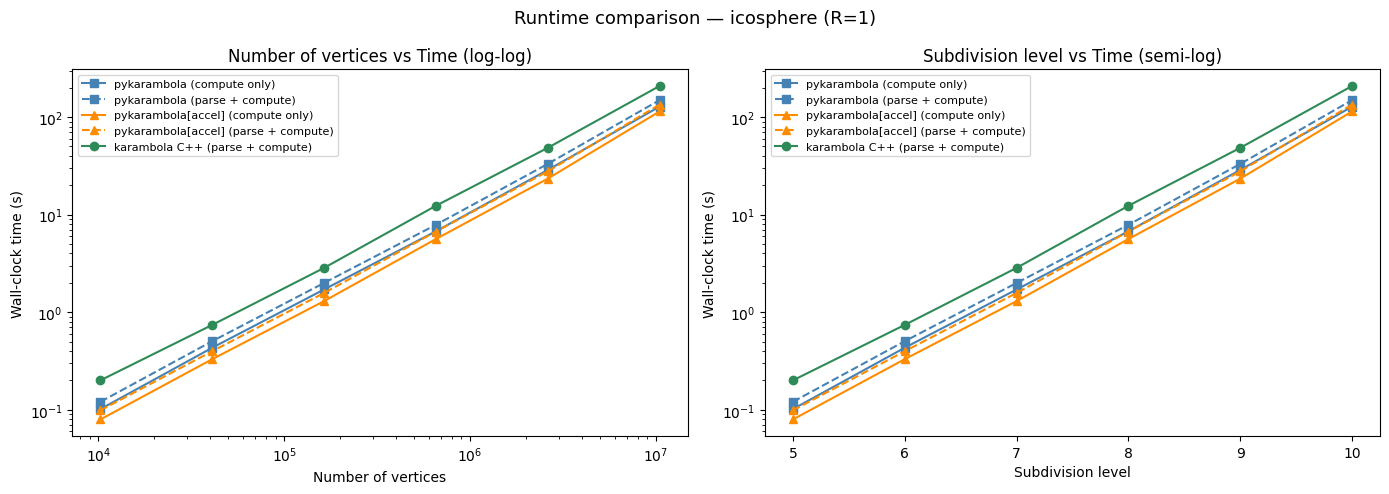

In [11]:
# ── Timing plots (log-log) ────────────────────────────────────────────────────
# Solid lines  = compute only (minkowski_tensors, mesh already parsed)
# Dashed lines = end-to-end (parse .off + compute)  ← fair comparison vs karambola
df = df_timing_all.sort_values('subdivision')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, x_col, x_label in [
    (axes[0], 'n_vertices',  'Number of vertices'),
    (axes[1], 'subdivision', 'Subdivision level'),
]:
    ax.plot(df[x_col], df['t_py_compute'], marker='s', color='steelblue',
            label='pykarambola (compute only)')
    ax.plot(df[x_col], df['t_py_total'],   marker='s', color='steelblue',
            ls='--', label='pykarambola (parse + compute)')

    if 't_accel_compute' in df.columns:
        ax.plot(df[x_col], df['t_accel_compute'], marker='^', color='darkorange',
                label='pykarambola[accel] (compute only)')
        ax.plot(df[x_col], df['t_accel_total'],   marker='^', color='darkorange',
                ls='--', label='pykarambola[accel] (parse + compute)')

    if 't_kara' in df.columns:
        ax.plot(df[x_col], df['t_kara'], marker='o', color='seagreen',
                label='karambola C++ (parse + compute)')

    ax.set_xlabel(x_label)
    ax.set_ylabel('Wall-clock time (s)')
    ax.set_title(f'{x_label} vs Time (semi-log)')
    ax.legend(fontsize=8)
    ax.set_yscale('log')
    if x_col == 'n_vertices':
        ax.set_xscale('log')
        ax.set_title(f'{x_label} vs Time (log-log)')


fig.suptitle('Runtime comparison — icosphere (R=1)', fontsize=13)
fig.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, 'timing_comparison.pdf'), bbox_inches='tight')
plt.show()

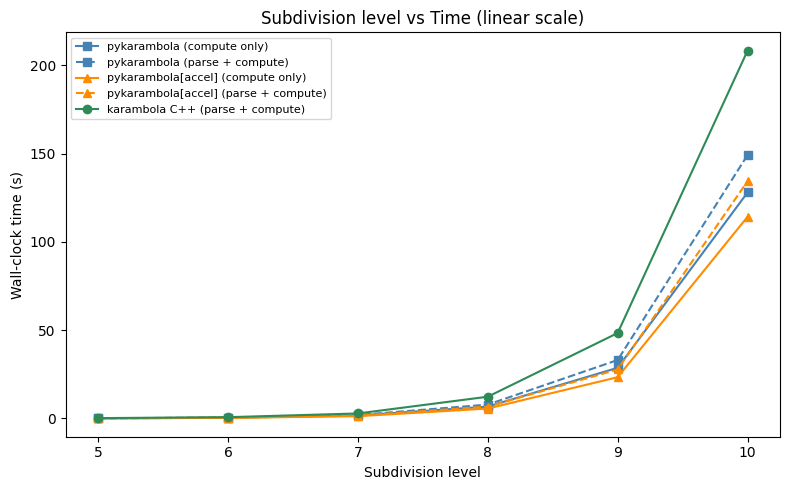

In [12]:
# ── Linear-scale: subdivisions vs time ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(df['subdivision'], df['t_py_compute'], marker='s', color='steelblue',
        label='pykarambola (compute only)')
ax.plot(df['subdivision'], df['t_py_total'],   marker='s', color='steelblue',
        ls='--', label='pykarambola (parse + compute)')

if 't_accel_compute' in df.columns:
    ax.plot(df['subdivision'], df['t_accel_compute'], marker='^', color='darkorange',
            label='pykarambola[accel] (compute only)')
    ax.plot(df['subdivision'], df['t_accel_total'],   marker='^', color='darkorange',
            ls='--', label='pykarambola[accel] (parse + compute)')

if 't_kara' in df.columns:
    ax.plot(df['subdivision'], df['t_kara'], marker='o', color='seagreen',
            label='karambola C++ (parse + compute)')

ax.set_xlabel('Subdivision level')
ax.set_ylabel('Wall-clock time (s)')
ax.set_title('Subdivision level vs Time (linear scale)')
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, 'timing_subdivisions_linear.pdf'), bbox_inches='tight')
plt.show()

In [14]:
# ── Scalar convergence plot (commented out — uncomment once karambola values loaded) ──
# ANALYTICAL = 4.0 * np.pi / 3.0
#
# fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
# axes = axes.ravel()
#
# for ax, key in zip(axes, SCALAR_KEYS):
#     ax.axhline(ANALYTICAL, color='k', ls='--', lw=1, label='Analytical (4π/3)')
#     ax.plot(df_py['n_vertices'], df_py[key], marker='s', label='pykarambola')
#     if df_accel is not None:
#         ax.plot(df_accel['n_vertices'], df_accel[key], marker='^', label='pykarambola[accel]')
#     if df_kara is not None:
#         ax.plot(df_kara['n_vertices'], df_kara[key], marker='o', label='karambola (C++)')
#     ax.set_title(key)
#     ax.set_xlabel('Number of vertices')
#     ax.set_xscale('log')
#     ax.legend(fontsize=8)
#
# fig.suptitle('Scalar Minkowski functionals vs mesh resolution\n'
#              'Icosphere R=1  (analytical = 4π/3 ≈ 4.18879)', fontsize=12)
# fig.tight_layout()
# fig.savefig(os.path.join(RESULTS_DIR, 'scalar_convergence.png'), dpi=150, bbox_inches='tight')
# plt.show()

In [15]:
# ── Numerical agreement (commented out — uncomment once karambola values loaded) ──
# if df_kara is None:
#     print("Load karambola results first (cells above).")
# else:
#     shared_subs = sorted(set(df_py['subdivision']) & set(df_kara['subdivision']))
#     rows = []
#     for sub in shared_subs:
#         row_py   = df_py  [df_py  ['subdivision'] == sub].iloc[0]
#         row_kara = df_kara[df_kara['subdivision'] == sub].iloc[0]
#         r = {'subdivision': sub, 'n_vertices': int(row_py['n_vertices'])}
#         for key in SCALAR_KEYS:
#             ref = abs(row_kara[key])
#             diff = abs(row_py[key] - row_kara[key])
#             r[f'reldiff_{key}'] = diff / ref if ref > 1e-12 else float('nan')
#         rows.append(r)
#     df_diff = pd.DataFrame(rows)
#     print("Relative difference |pykarambola − karambola| / |karambola|:")
#     print(df_diff.to_string(index=False))

In [13]:
# ── Speed-up table ────────────────────────────────────────────────────────────
if 't_kara' not in df_timing_all.columns:
    print("Load karambola timing first (kara-timing-load cell).")
else:
    d = df_timing_all.sort_values('subdivision').copy()
    d['speedup_py_compute']  = d['t_py_compute']  / d['t_kara']
    d['speedup_py_total']    = d['t_py_total']    / d['t_kara']

    cols = ['subdivision', 'n_vertices', 't_kara', 't_py_compute', 't_py_total',
            'speedup_py_compute', 'speedup_py_total']

    if 't_accel_compute' in d.columns:
        d['speedup_accel_compute'] = d['t_accel_compute'] / d['t_kara']
        d['speedup_accel_total']   = d['t_accel_total']   / d['t_kara']
        cols += ['t_accel_compute', 't_accel_total',
                 'speedup_accel_compute', 'speedup_accel_total']

    print(d[cols].to_string(index=False))

 subdivision  n_vertices     t_kara  t_py_compute  t_py_total  speedup_py_compute  speedup_py_total  t_accel_compute  t_accel_total  speedup_accel_compute  speedup_accel_total
           5       10242   0.200024      0.101496    0.120568            0.507418          0.602765         0.079481       0.098601               0.397358             0.492946
           6       40962   0.740378      0.431927    0.504119            0.583388          0.680895         0.329740       0.397780               0.445366             0.537266
           7      163842   2.843293      1.707901    1.992470            0.600677          0.700761         1.297967       1.573204               0.456501             0.553303
           8      655362  12.317813      6.745964    7.863679            0.547659          0.638399         5.617419       6.699238               0.456040             0.543866
           9     2621442  48.361936     28.681516   33.089571            0.593060          0.684207        23.371131    